----- BASE GRAPH (p = 0) -----
Average Clustering Coefficient : 0.6666666666666636
Average Shortest Path Length   : 50.450450450450454
Average Diameter               : 100.0
--------------------------------------------------

----- VARYING p (Averaged over trials) -----
p = 0      | Clustering = 0.6667 | Avg Path Length = 50.4505
p = 0.001  | Clustering = 0.6647 | Avg Path Length = 25.6920
p = 0.01   | Clustering = 0.6458 | Avg Path Length = 8.7149
p = 0.05   | Clustering = 0.5726 | Avg Path Length = 5.2202
p = 0.1    | Clustering = 0.4909 | Avg Path Length = 4.4352
p = 0.5    | Clustering = 0.0912 | Avg Path Length = 3.3831
p = 1      | Clustering = 0.0090 | Avg Path Length = 3.2678


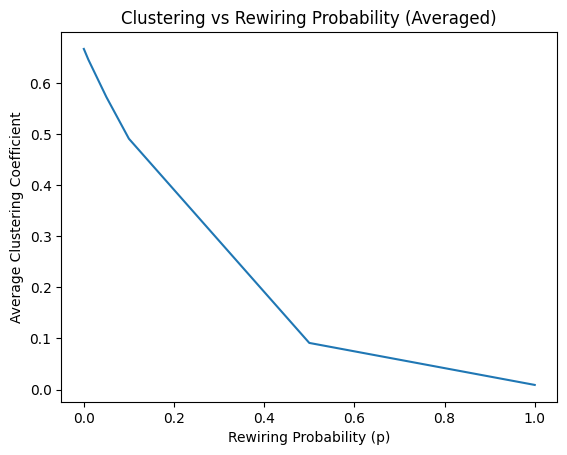

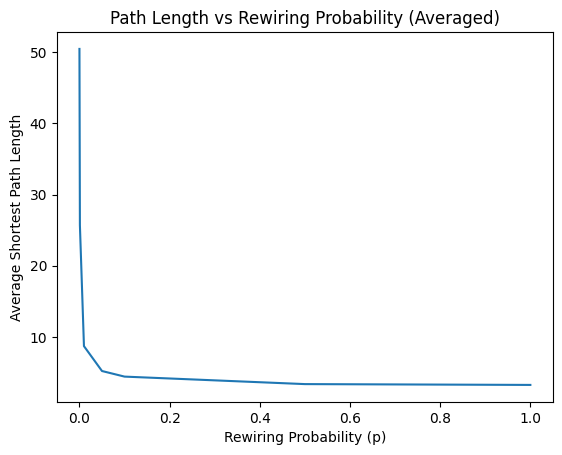

In [4]:

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

N = 1000
k = 10
p_values = [0, 0.001, 0.01, 0.05, 0.1, 0.5, 1]
trials = 5  

clustering_avg = []
path_length_avg = []

print("----- BASE GRAPH (p = 0) -----")

base_clustering = []
base_path = []
base_diameter = []

for _ in range(trials):
    G0 = nx.watts_strogatz_graph(N, k, 0)
    base_clustering.append(nx.average_clustering(G0))
    base_path.append(nx.average_shortest_path_length(G0))
    base_diameter.append(nx.diameter(G0))

print("Average Clustering Coefficient :", np.mean(base_clustering))
print("Average Shortest Path Length   :", np.mean(base_path))
print("Average Diameter               :", np.mean(base_diameter))
print("--------------------------------------------------\n")


print("----- VARYING p (Averaged over trials) -----")

for p in p_values:
    clustering_trials = []
    path_trials = []
    
    for _ in range(trials):
        G = nx.watts_strogatz_graph(N, k, p)
        
        # Ensure connected graph
        if not nx.is_connected(G):
            largest_component = max(nx.connected_components(G), key=len)
            G = G.subgraph(largest_component).copy()
        
        clustering_trials.append(nx.average_clustering(G))
        path_trials.append(nx.average_shortest_path_length(G))
    
    clustering_mean = np.mean(clustering_trials)
    path_mean = np.mean(path_trials)
    
    clustering_avg.append(clustering_mean)
    path_length_avg.append(path_mean)
    
    print(f"p = {p:<6} | Clustering = {clustering_mean:.4f} | Avg Path Length = {path_mean:.4f}")


plt.figure()
plt.plot(p_values, clustering_avg)
plt.xlabel("Rewiring Probability (p)")
plt.ylabel("Average Clustering Coefficient")
plt.title("Clustering vs Rewiring Probability (Averaged)")
plt.show()


plt.figure()
plt.plot(p_values, path_length_avg)
plt.xlabel("Rewiring Probability (p)")
plt.ylabel("Average Shortest Path Length")
plt.title("Path Length vs Rewiring Probability (Averaged)")
plt.show()
